In [ ]:
# =========================
# FULL CLEAN ML PIPELINE
# Sentiment Classification
# =========================

!pip -q install pandas numpy openpyxl scikit-learn matplotlib tensorflow transformers datasets accelerate

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import IsolationForest

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

Mounted at /content/drive


In [ ]:
# -------------------------
# 1) LOAD DATA
# -------------------------
file_path = "/content/drive/MyDrive/early Brand Dataset/h&m_marketing_dataset.xlsx"
df = pd.read_excel(file_path)

print("Original shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Original shape: (10000, 20)

Columns:
['post_id', 'text', 'timestamp', 'brand', 'sentiment', 'sentiment_score', 'likes', 'retweets', 'comments', 'user_id', 'platform', 'location', 'hashtags', 'label', 'followers_count', 'campaign_context', 'topic_category', 'engagement_score', 'virality_index', 'negative_ratio_flag']

First 5 rows:
            post_id                                               text  \
0  HNM_527A5AE66792  H&M garment collecting program is a step in th...   
1  HNM_1B0128B4F8A1  just tried hm new shoe collection leather qual...   
2  HNM_2538B494388E  h&m profits come from exploiting vulnerable wo...   
3  HNM_92581202EB14  h&m sustainability report shows real progress ...   
4  HNM_F34CE750CF72  hm new collection pricing is honestly delusion...   

            timestamp       brand sentiment  sentiment_score  likes  retweets  \
0 2024-01-01 01:43:30  H&M Studio  positive                1     22        24   
1 2024-01-01 05:44:59         H&M  positive                

In [ ]:
# -------------------------
# 2) CHOOSE COLUMNS
# -------------------------
TEXT_COL = "text"
TARGET_COL = "sentiment"
TIME_COL = "timestamp"
SCORE_COL = "sentiment_score"

required_cols = [TEXT_COL, TARGET_COL]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("\nUsing columns:")
print("TEXT_COL   =", TEXT_COL)
print("TARGET_COL =", TARGET_COL)
print("TIME_COL   =", TIME_COL)




Using columns:
TEXT_COL   = text
TARGET_COL = sentiment
TIME_COL   = timestamp


In [ ]:
# 3) BASIC DATA CHECK
# -------------------------
print("Shape before filtering:", df.shape)
print("Missing text:", df[TEXT_COL].isna().sum())
print("Missing target:", df[TARGET_COL].isna().sum())
print("Duplicate full rows:", df.duplicated().sum())

print("\nTarget distribution before cleaning:")
print(df[TARGET_COL].value_counts(dropna=False))


Shape before filtering: (10000, 20)
Missing text: 0
Missing target: 0
Duplicate full rows: 0

Target distribution before cleaning:
sentiment
negative    3897
positive    3287
neutral     2816
Name: count, dtype: int64


In [ ]:
# 4) CLEAN TARGET LABELS
# -------------------------
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip().str.lower()

label_map = {
    "positive": "positive",
    "pos": "positive",
    "negative": "negative",
    "neg": "negative",
    "neutral": "neutral",
    "neu": "neutral"
}

df[TARGET_COL] = df[TARGET_COL].replace(label_map)

valid_labels = ["positive", "negative", "neutral"]

before_rows = len(df)
df = df[df[TARGET_COL].isin(valid_labels)].copy()
after_rows = len(df)

print("Rows removed due to invalid labels:", before_rows - after_rows)
print("Shape after target cleaning:", df.shape)

print("\nTarget distribution after cleaning:")
print(df[TARGET_COL].value_counts())

Rows removed due to invalid labels: 0
Shape after target cleaning: (10000, 20)

Target distribution after cleaning:
sentiment
negative    3897
positive    3287
neutral     2816
Name: count, dtype: int64


In [ ]:
# 5) CLEAN TEXT
# -------------------------
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = text.replace("&", " and ")
    text = text.lower()

    # remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # remove mentions
    text = re.sub(r"@\w+", "", text)

    # remove hashtag symbol only, keep the word
    text = re.sub(r"#", "", text)

    # remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # remove numbers
    text = re.sub(r"\d+", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["text_clean"] = df[TEXT_COL].apply(clean_text)

print("Empty cleaned texts:", (df["text_clean"].str.strip() == "").sum())

print("\nSample cleaned text:")
print(df[[TEXT_COL, "text_clean"]].head())

Empty cleaned texts: 0

Sample cleaned text:
                                                text  \
0  H&M garment collecting program is a step in th...   
1  just tried hm new shoe collection leather qual...   
2  h&m profits come from exploiting vulnerable wo...   
3  h&m sustainability report shows real progress ...   
4  hm new collection pricing is honestly delusion...   

                                          text_clean  
0  h and m garment collecting program is a step i...  
1  just tried hm new shoe collection leather qual...  
2  h and m profits come from exploiting vulnerabl...  
3  h and m sustainability report shows real progr...  
4  hm new collection pricing is honestly delusion...  


In [ ]:
# -------------------------
# 6) FINAL ML DATASET
# Keep all usable rows
# -------------------------
before_rows = len(df)

df_ml = df[
    (df["text_clean"].notna()) &
    (df["text_clean"].str.strip() != "") &
    (df[TARGET_COL].notna())
].copy()

after_rows = len(df_ml)

print("Rows removed in final filtering:", before_rows - after_rows)
print("Final ML dataset shape:", df_ml.shape)

print("\nFinal class distribution:")
print(df_ml[TARGET_COL].value_counts())

print("\nFinal class percentages:")
print((df_ml[TARGET_COL].value_counts(normalize=True) * 100).round(2))

print("\nNull check:")
print(df_ml[[TEXT_COL, "text_clean", TARGET_COL]].isna().sum())


Rows removed in final filtering: 0
Final ML dataset shape: (10000, 21)

Final class distribution:
sentiment
negative    3897
positive    3287
neutral     2816
Name: count, dtype: int64

Final class percentages:
sentiment
negative    38.97
positive    32.87
neutral     28.16
Name: proportion, dtype: float64

Null check:
text          0
text_clean    0
sentiment     0
dtype: int64


In [ ]:
# -------------------------
# 7) FINAL CHECKS
# -------------------------
total_rows = len(df_ml)
unique_texts = df_ml["text_clean"].nunique()
duplicate_percentage = (1 - unique_texts / total_rows) * 100

print("Total rows:", total_rows)
print("Unique cleaned texts:", unique_texts)
print("Duplicate percentage:", round(duplicate_percentage, 2), "%")

Total rows: 10000
Unique cleaned texts: 216
Duplicate percentage: 97.84 %


In [ ]:
#8)Check for conflicting labels in duplicate texts

label_conflicts = (
    df_ml.groupby("text_clean")[TARGET_COL]
    .nunique()
    .reset_index(name="n_labels")
)

conflicting_texts = label_conflicts[label_conflicts["n_labels"] > 1]

print("Number of texts with conflicting labels:", conflicting_texts.shape[0])

if conflicting_texts.shape[0] > 0:
    print("\nExamples of conflicting texts:")
    conflict_examples = conflicting_texts["text_clean"].head(5).tolist()
    for i, txt in enumerate(conflict_examples, 1):
        print(f"\nConflict Example {i}:")
        print("Text:", txt)
        print(df_ml[df_ml["text_clean"] == txt][[TEXT_COL, "text_clean", TARGET_COL]].drop_duplicates())

Number of texts with conflicting labels: 0


In [ ]:
#9)Remove conflicting texts before final evaluation

conflict_text_list = conflicting_texts["text_clean"].tolist()

df_no_conflict = df_ml[~df_ml["text_clean"].isin(conflict_text_list)].copy()

print("Shape after removing conflicting-label texts:", df_no_conflict.shape)

Shape after removing conflicting-label texts: (10000, 21)


In [ ]:
#10)Create unique-text evaluation dataset
df_eval = df_no_conflict.drop_duplicates(subset=["text_clean"]).copy()

print("Rows after unique-text filtering:", df_eval.shape)
print("\nClass distribution in final evaluation dataset:")
print(df_eval[TARGET_COL].value_counts())

Rows after unique-text filtering: (216, 21)

Class distribution in final evaluation dataset:
sentiment
positive    72
negative    72
neutral     72
Name: count, dtype: int64


In [ ]:
# 11) TRAIN / TEST SPLIT
# -------------------------
X = df_eval["text_clean"]
y = df_eval[TARGET_COL]

print("Total rows used for final ML:", len(df_eval))
print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test split:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


Total rows used for final ML: 216
X shape: (216,)
y shape: (216,)

Train/Test split:
X_train shape: (172,)
X_test shape : (44,)
y_train shape: (172,)
y_test shape : (44,)


In [ ]:
# 12) TF-IDF + LOGISTIC REGRESSION Ml baseline
# -------------------------
logreg_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

In [ ]:
#13)Linear SVM model
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LinearSVC(random_state=42))
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

In [ ]:
# -------------------------
# 14) EVALUATION
# -------------------------
def evaluate_model(y_true, y_pred, model_name):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }
    return results

In [ ]:
#15)Compare model results
logreg_results = evaluate_model(y_test, y_pred_logreg, "Logistic Regression")
svm_results = evaluate_model(y_test, y_pred_svm, "Linear SVM")

results_df = pd.DataFrame([logreg_results, svm_results])

print("Final Results Table:")
print(results_df)

Final Results Table:
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.681818   0.697443  0.681818  0.685370
1           Linear SVM  0.681818   0.714572  0.681818  0.685108


In [ ]:
#16)Detailed classification reports
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_logreg, zero_division=0))

print("\nClassification Report - Linear SVM")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

    negative       0.56      0.64      0.60        14
     neutral       0.83      0.67      0.74        15
    positive       0.69      0.73      0.71        15

    accuracy                           0.68        44
   macro avg       0.69      0.68      0.68        44
weighted avg       0.70      0.68      0.69        44


Classification Report - Linear SVM
              precision    recall  f1-score   support

    negative       0.59      0.71      0.65        14
     neutral       0.90      0.60      0.72        15
    positive       0.65      0.73      0.69        15

    accuracy                           0.68        44
   macro avg       0.71      0.68      0.68        44
weighted avg       0.71      0.68      0.69        44



In [ ]:
#17)Confusion matrices
labels = ["negative", "neutral", "positive"]

cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=labels)
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels)

print("Confusion Matrix - Logistic Regression")
print(pd.DataFrame(cm_logreg, index=labels, columns=labels))

print("\nConfusion Matrix - Linear SVM")
print(pd.DataFrame(cm_svm, index=labels, columns=labels))

Confusion Matrix - Logistic Regression
          negative  neutral  positive
negative         9        2         3
neutral          3       10         2
positive         4        0        11

Confusion Matrix - Linear SVM
          negative  neutral  positive
negative        10        1         3
neutral          3        9         3
positive         4        0        11


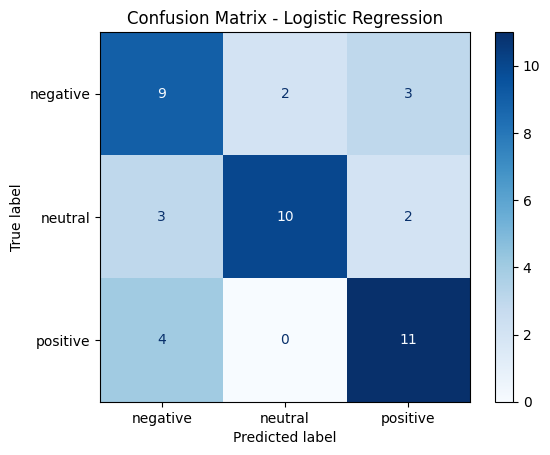

In [ ]:
#18)Plot confusion matrix for Logistic Regression
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=labels
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

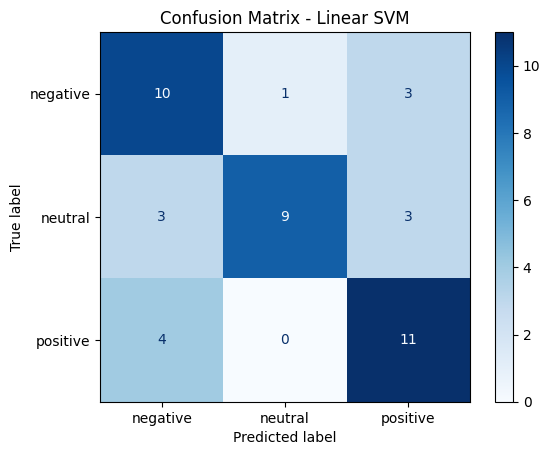

In [ ]:
#19)Plot confusion matrix for Linear SVM
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=labels
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Linear SVM")
plt.show()


In [ ]:
# 20) SAMPLE PREDICTIONS
# -------------------------
results_predictions = pd.DataFrame({
    "text_clean": X_test.values,
    "actual": y_test.values,
    "pred_logreg": y_pred_logreg,
    "pred_svm": y_pred_svm
})

print("Sample predictions:")
print(results_predictions.head(10))

Sample predictions:
                                          text_clean    actual pred_logreg  \
0  h and m uses more synthetic fossil fuel based ...  negative    negative   
1  shopping at h and m doesnt feel like a comprom...  positive    negative   
2  h and m spring collection is giving high fashi...  positive    positive   
3  h and m sustainability targets keep getting pu...  negative    negative   
4  hm quality varies significantly between produc...   neutral     neutral   
5  h and m promised living wages by and its still...  negative    positive   
6  h and m studio collection just dropped and its...  positive    positive   
7  got linen trousers from hm for thats insane qu...  positive    negative   
8  hm new collection pricing is honestly delusion...  negative     neutral   
9  scored amazing deals at the h and m mid season...  positive    positive   

   pred_svm  
0  negative  
1  negative  
2  positive  
3  negative  
4   neutral  
5  positive  
6  positive  
7  negati

In [ ]:
# -------------------------
# 21) Cross-validation on final dataset
# -------------------------
cv_scores_logreg = cross_val_score(
    logreg_model,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)

cv_scores_svm = cross_val_score(
    svm_model,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)

print("Logistic Regression CV F1 scores:", cv_scores_logreg)
print("Logistic Regression Mean CV F1:", cv_scores_logreg.mean())

print("\nLinear SVM CV F1 scores:", cv_scores_svm)
print("Linear SVM Mean CV F1:", cv_scores_svm.mean())

Logistic Regression CV F1 scores: [0.5678904  0.74009824 0.63662791 0.60465116 0.6809231 ]
Logistic Regression Mean CV F1: 0.6460381611534023

Linear SVM CV F1 scores: [0.52275443 0.68955239 0.61627907 0.5797915  0.63337788]
Linear SVM Mean CV F1: 0.6083510536289592


In [ ]:
#21) Save cleaned dataset and results

cleaned_output_path = "/content/drive/MyDrive/early Brand Dataset/hm_cleaned_for_ml.xlsx"
results_output_path = "/content/drive/MyDrive/early Brand Dataset/final_model_results.csv"
predictions_output_path = "/content/drive/MyDrive/early Brand Dataset/final_predictions.csv"
cm_logreg_output_path = "/content/drive/MyDrive/early Brand Dataset/confusion_matrix_logreg.csv"
cm_svm_output_path = "/content/drive/MyDrive/early Brand Dataset/confusion_matrix_svm.csv"

df_eval.to_excel(cleaned_output_path, index=False)
results_df.to_csv(results_output_path, index=False)
results_predictions.to_csv(predictions_output_path, index=False)

pd.DataFrame(cm_logreg, index=labels, columns=labels).to_csv(cm_logreg_output_path)
pd.DataFrame(cm_svm, index=labels, columns=labels).to_csv(cm_svm_output_path)

print("Saved cleaned evaluation dataset to:", cleaned_output_path)
print("Saved model results to:", results_output_path)
print("Saved predictions to:", predictions_output_path)
print("Saved Logistic Regression confusion matrix to:", cm_logreg_output_path)
print("Saved Linear SVM confusion matrix to:", cm_svm_output_path)

Saved cleaned evaluation dataset to: /content/drive/MyDrive/early Brand Dataset/hm_cleaned_for_ml.xlsx
Saved model results to: /content/drive/MyDrive/early Brand Dataset/final_model_results.csv
Saved predictions to: /content/drive/MyDrive/early Brand Dataset/final_predictions.csv
Saved Logistic Regression confusion matrix to: /content/drive/MyDrive/early Brand Dataset/confusion_matrix_logreg.csv
Saved Linear SVM confusion matrix to: /content/drive/MyDrive/early Brand Dataset/confusion_matrix_svm.csv


In [ ]:
#22)Optional summary text for report writing

print("SUMMARY")
print("-------")
print(f"Original rows after cleaning: {len(df_ml)}")
print(f"Unique cleaned texts used for final evaluation: {len(df_eval)}")
print(f"Duplicate percentage in dataset: {round(duplicate_percentage, 2)}%")
print(f"Conflicting-label texts removed: {len(conflict_text_list)}")
print("\nFinal model comparison:")
print(results_df)

SUMMARY
-------
Original rows after cleaning: 10000
Unique cleaned texts used for final evaluation: 216
Duplicate percentage in dataset: 97.84%
Conflicting-label texts removed: 0

Final model comparison:
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.681818   0.697443  0.681818  0.685370
1           Linear SVM  0.681818   0.714572  0.681818  0.685108


In [ ]:
# =========================
#28) LSTM MODEL (AFTER SPLIT)
# =========================

MAX_WORDS = 2000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

label_encoder = LabelEncoder()
y_train_lstm = label_encoder.fit_transform(y_train)
y_test_lstm = label_encoder.transform(y_test)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_lstm),
    y=y_train_lstm
)
class_weights = dict(enumerate(class_weights))

num_classes = len(label_encoder.classes_)

lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128),
    Bidirectional(LSTM(32, dropout=0.3, recurrent_dropout=0.3)),
    Dense(32, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_pad,
    y_train_lstm,
    validation_split=0.1,
    epochs=7,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/7
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 446ms/step - accuracy: 0.2987 - loss: 1.1007 - val_accuracy: 0.2778 - val_loss: 1.1073
Epoch 2/7
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 280ms/step - accuracy: 0.3896 - loss: 1.0930 - val_accuracy: 0.1667 - val_loss: 1.1193
Epoch 3/7
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.4091 - loss: 1.0822 - val_accuracy: 0.1667 - val_loss: 1.1091


In [ ]:
#30)Predict and evaluate LSTM
y_pred_prob_lstm = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_prob_lstm, axis=1)

lstm_results = {
    "Model": "LSTM",
    "Accuracy": accuracy_score(y_test_lstm, y_pred_lstm),
    "Precision": precision_score(y_test_lstm, y_pred_lstm, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_lstm, y_pred_lstm, average="weighted", zero_division=0),
    "F1-score": f1_score(y_test_lstm, y_pred_lstm, average="weighted", zero_division=0)
}

lstm_results_df = pd.DataFrame([lstm_results])

print("LSTM Results:")
print(lstm_results_df)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
LSTM Results:
  Model  Accuracy  Precision    Recall  F1-score
0  LSTM  0.272727   0.093126  0.272727  0.138843


In [ ]:
#31)LSTM confusion matrix and report
labels_names = list(label_encoder.classes_)
labels_encoded = list(range(len(labels_names)))

cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm, labels=labels_encoded)

print("Confusion Matrix - LSTM")
print(pd.DataFrame(cm_lstm, index=labels_names, columns=labels_names))

print("\nClassification Report - LSTM")
print(classification_report(y_test_lstm, y_pred_lstm, target_names=labels_names, zero_division=0))

Confusion Matrix - LSTM
          negative  neutral  positive
negative        12        2         0
neutral         15        0         0
positive        14        1         0

Classification Report - LSTM
              precision    recall  f1-score   support

    negative       0.29      0.86      0.44        14
     neutral       0.00      0.00      0.00        15
    positive       0.00      0.00      0.00        15

    accuracy                           0.27        44
   macro avg       0.10      0.29      0.15        44
weighted avg       0.09      0.27      0.14        44



In [ ]:
#32) Save LSTM results
lstm_results_df.to_csv("lstm_results_deduplicated.csv", index=False)
pd.DataFrame(cm_lstm, index=labels_names, columns=labels_names).to_csv("confusion_matrix_lstm_deduplicated.csv")

print("Saved LSTM results and confusion matrix.")

Saved LSTM results and confusion matrix.


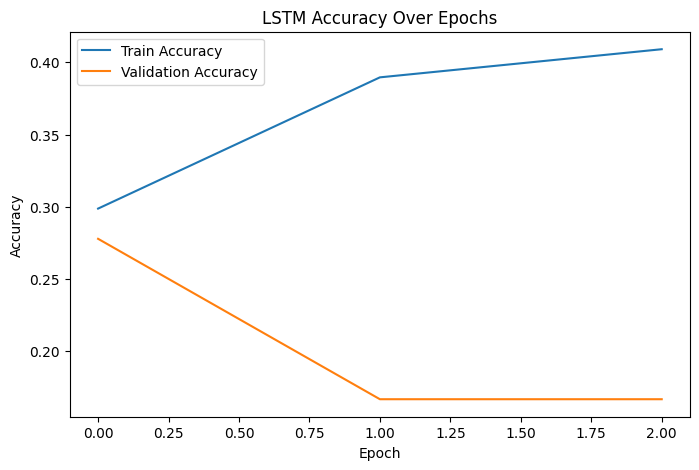

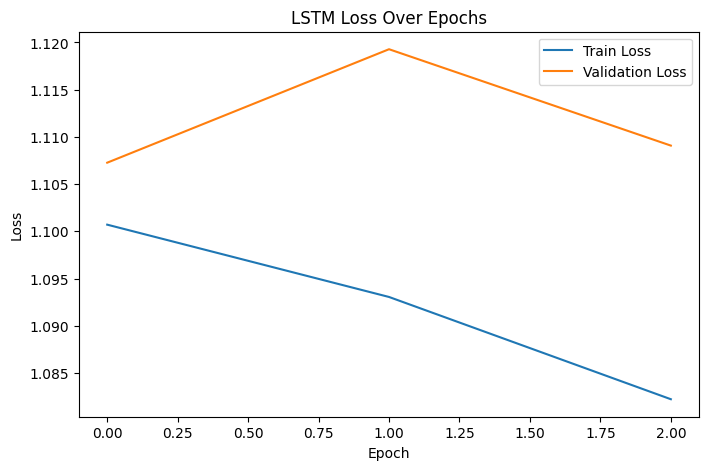

In [ ]:
#33)Plot LSTM training history
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
#34) Prepare BERT labels and text
bert_label_encoder = LabelEncoder()
y_train_bert = bert_label_encoder.fit_transform(y_train)
y_test_bert = bert_label_encoder.transform(y_test)

X_train_list = X_train.tolist()
X_test_list = X_test.tolist()

print("BERT class mapping:")
for idx, cls in enumerate(bert_label_encoder.classes_):
    print(f"{cls} -> {idx}")

BERT class mapping:
negative -> 0
neutral -> 1
positive -> 2


In [ ]:
#35) Tokenize for BERT
model_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = bert_tokenizer(
    X_train_list,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = bert_tokenizer(
    X_test_list,
    truncation=True,
    padding=True,
    max_length=128
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
#36) Create Torch dataset class
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, y_train_bert)
test_dataset = SentimentDataset(test_encodings, y_test_bert)

In [ ]:
# 37)Load BERT model
num_labels = len(bert_label_encoder.classes_)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#38)Define BERT metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall": recall_score(labels, preds, average="weighted", zero_division=0),
        "f1": f1_score(labels, preds, average="weighted", zero_division=0)
    }

In [ ]:
#39) BERT training arguments
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=10,
    report_to="none"
)

In [ ]:
#40) Train BERT
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.016577,0.919759,0.613636,0.818892,0.613636,0.548487
2,0.771721,0.752381,0.863636,0.865487,0.863636,0.861810
3,0.621040,0.671319,0.863636,0.864401,0.863636,0.863365


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=66, training_loss=0.8143794283722386, metrics={'train_runtime': 261.9035, 'train_samples_per_second': 1.97, 'train_steps_per_second': 0.252, 'total_flos': 6098886799992.0, 'train_loss': 0.8143794283722386, 'epoch': 3.0})

In [ ]:
#41)Evaluate BERT
bert_eval = trainer.evaluate()
print("BERT Evaluation:")
print(bert_eval)

pred_output = trainer.predict(test_dataset)
y_pred_bert = np.argmax(pred_output.predictions, axis=1)

bert_results = {
    "Model": "BERT",
    "Accuracy": bert_eval["eval_accuracy"],
    "Precision": bert_eval["eval_precision"],
    "Recall": bert_eval["eval_recall"],
    "F1-score": bert_eval["eval_f1"]
}

bert_results_df = pd.DataFrame([bert_results])
print(bert_results_df)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


BERT Evaluation:
{'eval_loss': 0.6713190078735352, 'eval_accuracy': 0.8636363636363636, 'eval_precision': 0.8644012237762237, 'eval_recall': 0.8636363636363636, 'eval_f1': 0.8633648311067664, 'eval_runtime': 3.6005, 'eval_samples_per_second': 12.22, 'eval_steps_per_second': 1.666, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Model  Accuracy  Precision    Recall  F1-score
0  BERT  0.863636   0.864401  0.863636  0.863365


In [ ]:
#42)BERT confusion matrix and report
cm_bert = confusion_matrix(y_test_bert, y_pred_bert)

print("Confusion Matrix - BERT")
print(pd.DataFrame(
    cm_bert,
    index=bert_label_encoder.classes_,
    columns=bert_label_encoder.classes_
))

print("\nClassification Report - BERT")
print(classification_report(
    y_test_bert,
    y_pred_bert,
    target_names=bert_label_encoder.classes_,
    zero_division=0
))

Confusion Matrix - BERT
          negative  neutral  positive
negative        11        1         2
neutral          0       14         1
positive         2        0        13

Classification Report - BERT
              precision    recall  f1-score   support

    negative       0.85      0.79      0.81        14
     neutral       0.93      0.93      0.93        15
    positive       0.81      0.87      0.84        15

    accuracy                           0.86        44
   macro avg       0.86      0.86      0.86        44
weighted avg       0.86      0.86      0.86        44



In [ ]:
#42)Save BERT results
bert_results_df.to_csv("bert_results_deduplicated.csv", index=False)
pd.DataFrame(
    cm_bert,
    index=bert_label_encoder.classes_,
    columns=bert_label_encoder.classes_
).to_csv("confusion_matrix_bert_deduplicated.csv")

print("Saved BERT results.")

Saved BERT results.


In [ ]:
#43)Final model comparison


comparison_df = pd.concat([results_df, lstm_results_df, bert_results_df], ignore_index=True)

print("ML vs LSTM vs BERT Comparison:")
print(comparison_df)

comparison_df.to_csv("model_comparison_ml_lstm_bert.csv", index=False)
print("Saved final comparison table.")

ML vs LSTM vs BERT Comparison:
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.681818   0.697443  0.681818  0.685370
1           Linear SVM  0.681818   0.714572  0.681818  0.685108
2                 LSTM  0.272727   0.093126  0.272727  0.138843
3                 BERT  0.863636   0.864401  0.863636  0.863365
Saved final comparison table.


In [ ]:
LABEL_COL = "sentiment"

required_cols = [TIME_COL, LABEL_COL, SCORE_COL]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns for time analysis: {missing_cols}")

df_time = df[[TIME_COL, LABEL_COL, SCORE_COL]].dropna().copy()
df_time[TIME_COL] = pd.to_datetime(df_time[TIME_COL], errors="coerce")
df_time = df_time.dropna(subset=[TIME_COL]).copy()
df_time["is_negative"] = (df_time[LABEL_COL].astype(str).str.lower() == "negative").astype(int)

print("Time-series dataset shape:", df_time.shape)
print(df_time.head())

Time-series dataset shape: (10000, 4)
            timestamp sentiment  sentiment_score  is_negative
0 2024-01-01 01:43:30  positive                1            0
1 2024-01-01 05:44:59  positive                1            0
2 2024-01-01 07:44:59  negative               -1            1
3 2024-01-01 08:58:53  positive                1            0
4 2024-01-01 11:21:06  negative               -1            1


In [ ]:
#44)Daily sentiment time series
daily_ts = (
    df_time
    .set_index(TIME_COL)
    .resample("D")
    .agg(
        post_volume=(LABEL_COL, "count"),
        negative_posts=("is_negative", "sum"),
        avg_sentiment_score=(SCORE_COL, "mean")
    )
)

daily_ts["negative_percent"] = (daily_ts["negative_posts"] / daily_ts["post_volume"]) * 100

# Filter very low-volume days
daily_ts = daily_ts[daily_ts["post_volume"] > 5].copy()

print(daily_ts.head())

            post_volume  negative_posts  avg_sentiment_score  negative_percent
timestamp                                                                     
2024-01-01           14               5             0.142857         35.714286
2024-01-02            9               3             0.111111         33.333333
2024-01-03           10               3             0.200000         30.000000
2024-01-04            6               2             0.166667         33.333333
2024-01-05           16               3             0.187500         18.750000


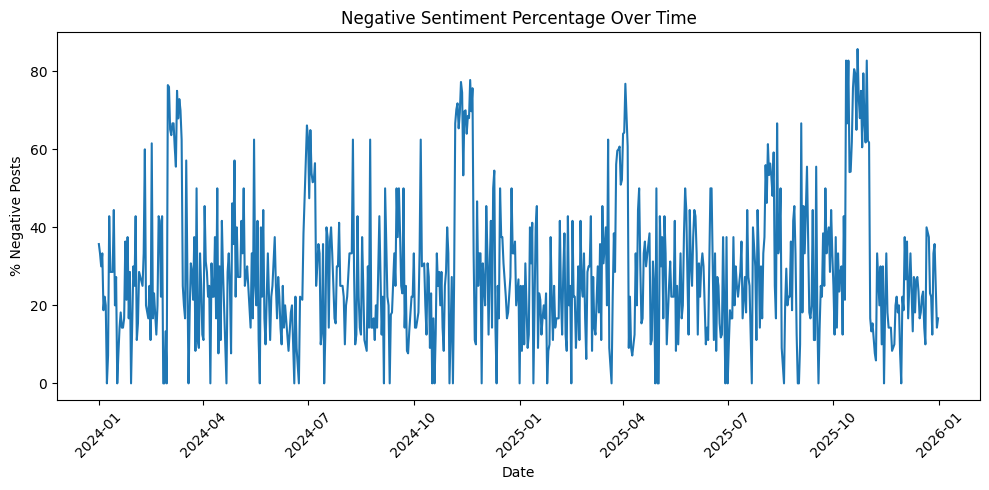

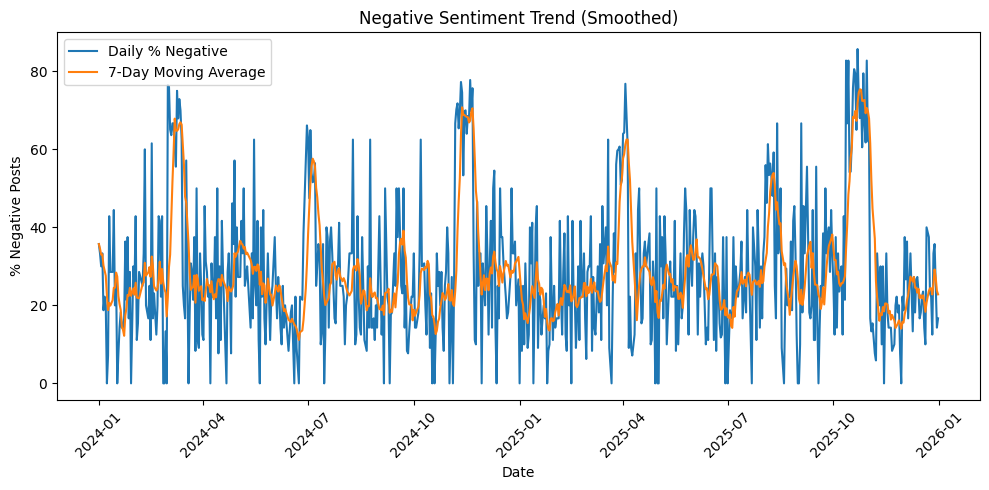

In [ ]:
#45)Plot daily and smoothed sentiment trends
plt.figure(figsize=(10, 5))
plt.plot(daily_ts.index, daily_ts["negative_percent"])
plt.title("Negative Sentiment Percentage Over Time")
plt.xlabel("Date")
plt.ylabel("% Negative Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

daily_ts["negative_percent_7d_ma"] = daily_ts["negative_percent"].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(daily_ts.index, daily_ts["negative_percent"], label="Daily % Negative")
plt.plot(daily_ts.index, daily_ts["negative_percent_7d_ma"], label="7-Day Moving Average")
plt.title("Negative Sentiment Trend (Smoothed)")
plt.xlabel("Date")
plt.ylabel("% Negative Posts")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

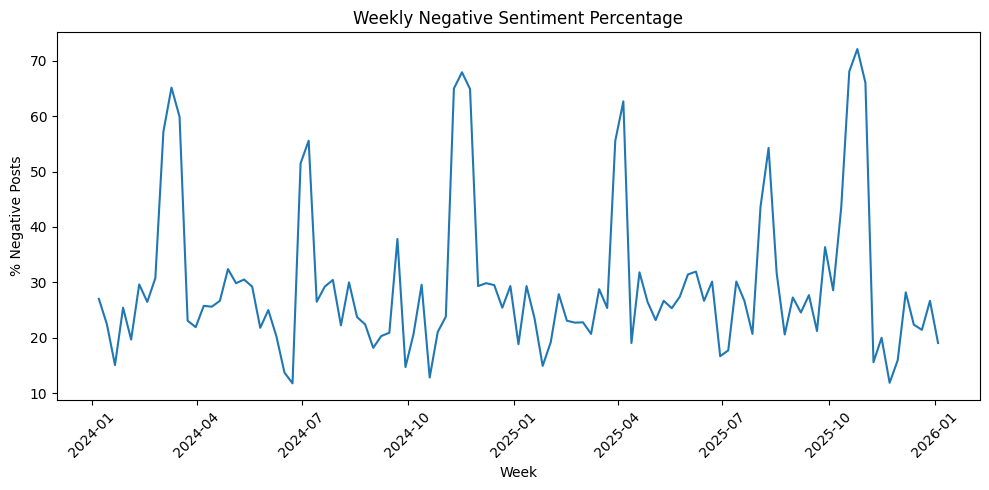

In [ ]:
#46)) Weekly sentiment trend
weekly_ts = (
    df_time
    .set_index(TIME_COL)
    .resample("W")
    .agg(
        post_volume=(LABEL_COL, "count"),
        negative_posts=("is_negative", "sum"),
        avg_sentiment_score=(SCORE_COL, "mean")
    )
)

weekly_ts["negative_percent"] = (weekly_ts["negative_posts"] / weekly_ts["post_volume"]) * 100

plt.figure(figsize=(10, 5))
plt.plot(weekly_ts.index, weekly_ts["negative_percent"])
plt.title("Weekly Negative Sentiment Percentage")
plt.xlabel("Week")
plt.ylabel("% Negative Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#47)Save time-series results
daily_ts.to_csv("daily_sentiment_time_series.csv")
weekly_ts.to_csv("weekly_sentiment_time_series.csv")

print("Saved daily and weekly time series.")

Saved daily and weekly time series.


In [ ]:
#48)Z-score anomaly detection
WINDOW = 7

daily_ts["neg_roll_mean"] = daily_ts["negative_percent"].rolling(window=WINDOW, min_periods=1).mean()
daily_ts["neg_roll_std"] = daily_ts["negative_percent"].rolling(window=WINDOW, min_periods=1).std()

daily_ts["neg_zscore"] = (
    (daily_ts["negative_percent"] - daily_ts["neg_roll_mean"]) /
    daily_ts["neg_roll_std"]
)

daily_ts["neg_zscore"] = daily_ts["neg_zscore"].replace([np.inf, -np.inf], np.nan).fillna(0)

Z_THRESHOLD = 2.0
daily_ts["z_anomaly"] = (daily_ts["neg_zscore"] > Z_THRESHOLD).astype(int)

print("Number of z-score anomalies:", daily_ts["z_anomaly"].sum())

Number of z-score anomalies: 6


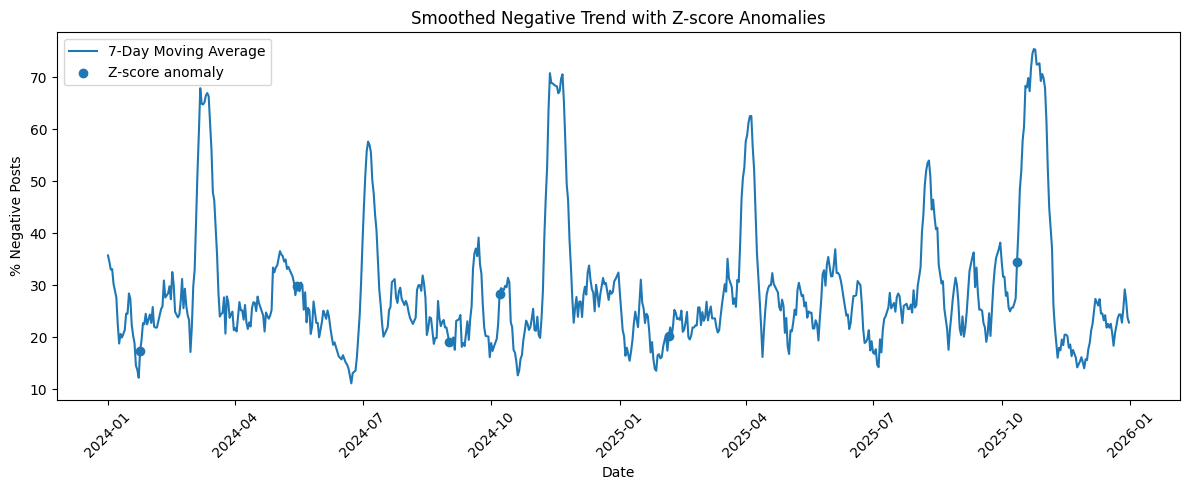

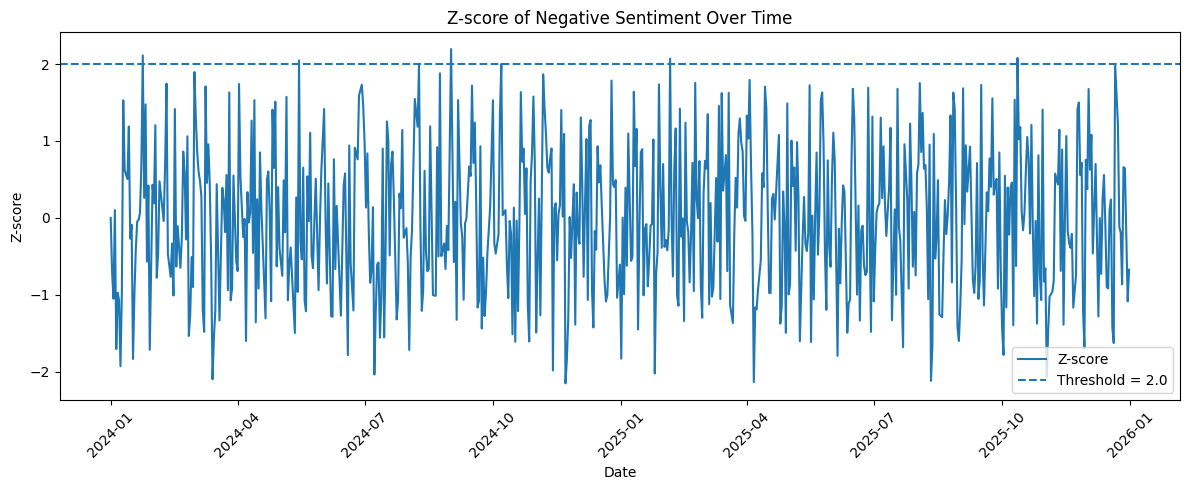

In [ ]:
#49) Plot z-score anomalies
plt.figure(figsize=(12, 5))
plt.plot(daily_ts.index, daily_ts["negative_percent_7d_ma"], label="7-Day Moving Average")
plt.scatter(
    daily_ts.index[daily_ts["z_anomaly"] == 1],
    daily_ts["negative_percent_7d_ma"][daily_ts["z_anomaly"] == 1],
    label="Z-score anomaly",
    marker="o"
)
plt.title("Smoothed Negative Trend with Z-score Anomalies")
plt.xlabel("Date")
plt.ylabel("% Negative Posts")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(daily_ts.index, daily_ts["neg_zscore"], label="Z-score")
plt.axhline(y=2.0, linestyle="--", label="Threshold = 2.0")
plt.title("Z-score of Negative Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#50)) Isolation Forest anomaly detection
features_if = daily_ts[["negative_percent", "avg_sentiment_score", "post_volume"]].copy()
features_if = features_if.ffill().bfill()

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_model.fit(features_if)

daily_ts["iforest_pred"] = iso_model.predict(features_if)
daily_ts["iforest_anomaly"] = (daily_ts["iforest_pred"] == -1).astype(int)

print("Number of Isolation Forest anomalies:", daily_ts["iforest_anomaly"].sum())

Number of Isolation Forest anomalies: 34


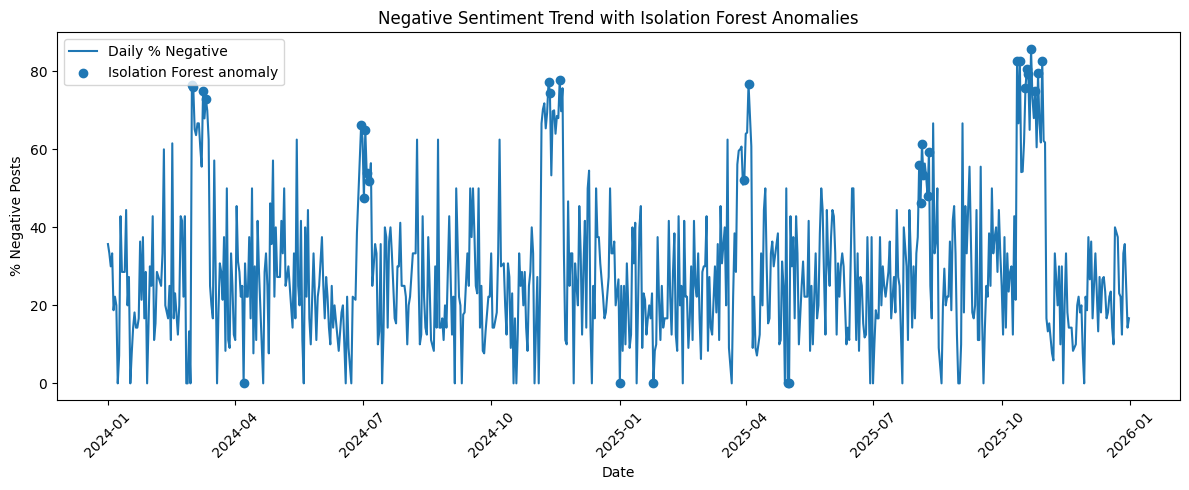

In [ ]:
#51) Plot Isolation Forest anomalies
plt.figure(figsize=(12, 5))
plt.plot(daily_ts.index, daily_ts["negative_percent"], label="Daily % Negative")
plt.scatter(
    daily_ts.index[daily_ts["iforest_anomaly"] == 1],
    daily_ts["negative_percent"][daily_ts["iforest_anomaly"] == 1],
    label="Isolation Forest anomaly",
    marker="o"
)
plt.title("Negative Sentiment Trend with Isolation Forest Anomalies")
plt.xlabel("Date")
plt.ylabel("% Negative Posts")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#52)Agreed anomalies
daily_ts["agreed_anomaly"] = (
    (daily_ts["z_anomaly"] == 1) &
    (daily_ts["iforest_anomaly"] == 1)
).astype(int)

print("Number of agreed anomalies:", daily_ts["agreed_anomaly"].sum())

Number of agreed anomalies: 1


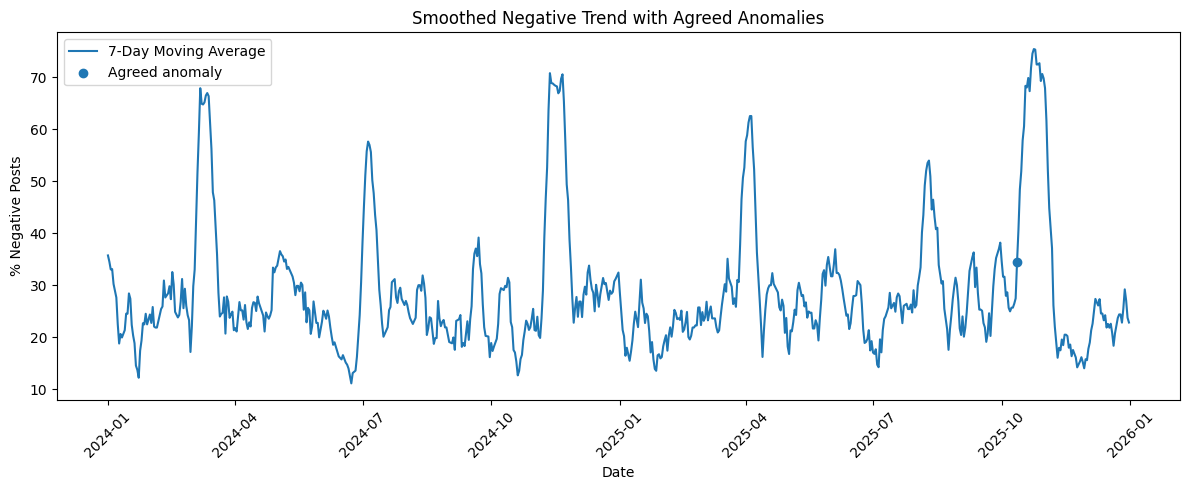

In [ ]:
#53)Plot agreed anomalies
plt.figure(figsize=(12, 5))
plt.plot(daily_ts.index, daily_ts["negative_percent_7d_ma"], label="7-Day Moving Average")
plt.scatter(
    daily_ts.index[daily_ts["agreed_anomaly"] == 1],
    daily_ts["negative_percent_7d_ma"][daily_ts["agreed_anomaly"] == 1],
    label="Agreed anomaly",
    marker="o"
)
plt.title("Smoothed Negative Trend with Agreed Anomalies")
plt.xlabel("Date")
plt.ylabel("% Negative Posts")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#54)) Save anomaly results
daily_ts.to_csv("daily_sentiment_with_all_anomalies.csv")
print("Saved anomaly detection results.")

Saved anomaly detection results.


In [ ]:
#55) Anomaly summary table
summary_anomaly = pd.DataFrame({
    "Method": ["Z-score", "Isolation Forest", "Agreed"],
    "Anomalies Detected": [
        int(daily_ts["z_anomaly"].sum()),
        int(daily_ts["iforest_anomaly"].sum()),
        int(daily_ts["agreed_anomaly"].sum())
    ]
})

print("Anomaly Detection Summary:")
print(summary_anomaly)

Anomaly Detection Summary:
             Method  Anomalies Detected
0           Z-score                   6
1  Isolation Forest                  34
2            Agreed                   1


In [ ]:
#6) Build hybrid crisis score
WINDOW = 7

daily_ts["volume_roll_mean"] = daily_ts["post_volume"].rolling(window=WINDOW, min_periods=1).mean()
daily_ts["volume_ratio"] = daily_ts["post_volume"] / daily_ts["volume_roll_mean"]

def minmax_scale(series):
    s_min = series.min()
    s_max = series.max()
    if s_max == s_min:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - s_min) / (s_max - s_min)

daily_ts["neg_score_norm"] = minmax_scale(daily_ts["negative_percent"])
daily_ts["vol_score_norm"] = minmax_scale(daily_ts["volume_ratio"])

daily_ts["anomaly_score"] = (
    0.4 * daily_ts["z_anomaly"] +
    0.4 * daily_ts["iforest_anomaly"] +
    0.2 * daily_ts["agreed_anomaly"]
)

daily_ts["crisis_score"] = (
    0.5 * daily_ts["neg_score_norm"] +
    0.3 * daily_ts["anomaly_score"] +
    0.2 * daily_ts["vol_score_norm"]
)

print(daily_ts[["negative_percent", "anomaly_score", "volume_ratio", "crisis_score"]].head())

            negative_percent  anomaly_score  volume_ratio  crisis_score
timestamp                                                              
2024-01-01         35.714286            0.0      1.000000      0.252119
2024-01-02         33.333333            0.0      0.782609      0.227417
2024-01-03         30.000000            0.0      0.909091      0.214264
2024-01-04         33.333333            0.0      0.615385      0.219100
2024-01-05         18.750000            0.0      1.454545      0.175768


In [ ]:
print(daily_ts[["crisis_score"]].describe())
print(daily_ts[["anomaly_score"]].head(10))

       crisis_score
count    673.000000
mean       0.221183
std        0.129344
min        0.012101
25%        0.126677
50%        0.196680
75%        0.274061
max        0.886552
            anomaly_score
timestamp                
2024-01-01            0.0
2024-01-02            0.0
2024-01-03            0.0
2024-01-04            0.0
2024-01-05            0.0
2024-01-06            0.0
2024-01-07            0.0
2024-01-08            0.0
2024-01-09            0.0
2024-01-10            0.0


In [ ]:
#57) Assign alert levels
print(daily_ts["crisis_score"].describe())
print(daily_ts["crisis_score"].quantile([0.90, 0.95, 0.98, 0.99]))

def assign_alert_level(score):
    if score >= 0.75:
        return "HIGH"
    elif score >= 0.55:
        return "MEDIUM"
    elif score >= 0.40:
        return "LOW"
    else:
        return "NORMAL"

daily_ts["alert_level"] = daily_ts["crisis_score"].apply(assign_alert_level)
daily_ts["alert_flag"] = daily_ts["alert_level"].isin(["MEDIUM", "HIGH"]).astype(int)

print(daily_ts["alert_level"].value_counts())
print(daily_ts["alert_flag"].value_counts())
print(daily_ts[["crisis_score", "alert_level"]].sort_values("crisis_score", ascending=False).head(15))

count    673.000000
mean       0.221183
std        0.129344
min        0.012101
25%        0.126677
50%        0.196680
75%        0.274061
max        0.886552
Name: crisis_score, dtype: float64
0.90    0.407497
0.95    0.481805
0.98    0.610067
0.99    0.638380
Name: crisis_score, dtype: float64
alert_level
NORMAL    600
LOW        52
MEDIUM     20
HIGH        1
Name: count, dtype: int64
alert_flag
0    652
1     21
Name: count, dtype: int64
            crisis_score alert_level
timestamp                           
2025-10-12      0.886552        HIGH
2024-03-01      0.721545      MEDIUM
2024-03-02      0.672665      MEDIUM
2025-10-14      0.671046      MEDIUM
2025-10-22      0.661835      MEDIUM
2025-08-03      0.646389      MEDIUM
2025-10-30      0.642910      MEDIUM
2025-10-19      0.636618      MEDIUM
2025-10-27      0.636503      MEDIUM
2025-10-20      0.628088      MEDIUM
2025-04-03      0.621579      MEDIUM
2024-06-30      0.619059      MEDIUM
2024-11-12      0.616800      MEDIU

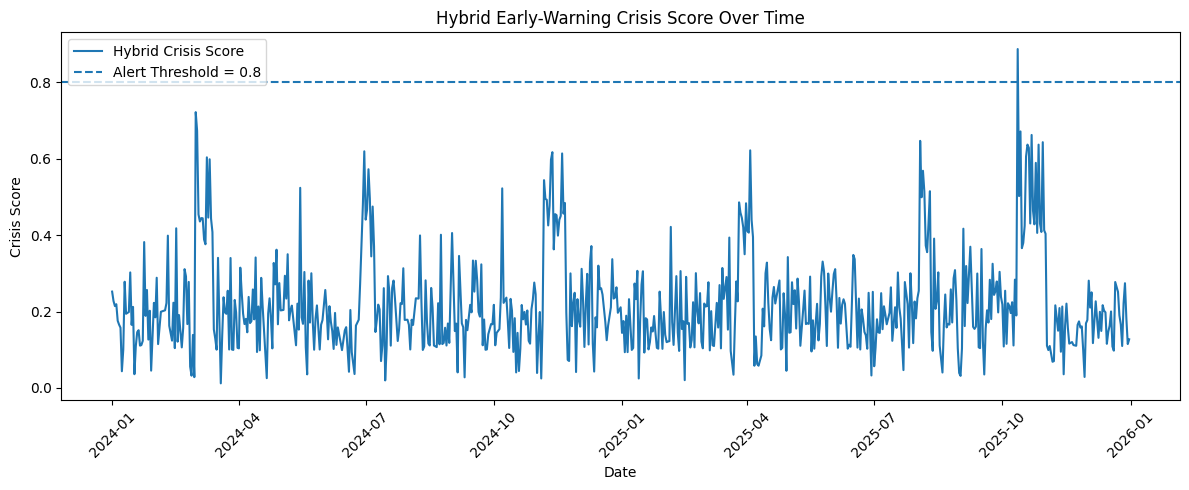

In [ ]:
#58)Plot crisis score
ALERT_THRESHOLD = 0.80

plt.figure(figsize=(12, 5))
plt.plot(daily_ts.index, daily_ts["crisis_score"], label="Hybrid Crisis Score")
plt.axhline(y=ALERT_THRESHOLD, linestyle="--", label=f"Alert Threshold = {ALERT_THRESHOLD}")
plt.title("Hybrid Early-Warning Crisis Score Over Time")
plt.xlabel("Date")
plt.ylabel("Crisis Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#59 Peak crisis and lead-time analysis
peak_time = daily_ts["crisis_score"].idxmax()
peak_score = daily_ts["crisis_score"].max()

alerts_before_peak = daily_ts[
    (daily_ts.index < peak_time) &
    (daily_ts["alert_flag"] == 1)
].copy()

if len(alerts_before_peak) > 0:

    # 🔥 closest alert (IMPORTANT)
    closest_alert_time = alerts_before_peak.index[-1]

    # optional: first ever alert
    first_alert_time = alerts_before_peak.index[0]

    lead_time = peak_time - closest_alert_time

    print("Peak:", peak_time)
    print("Closest alert before peak:", closest_alert_time)
    print("Lead-time:", lead_time)
    print(f"Lead-time (days): {lead_time.days}")

else:
    print("No alerts before peak.")

Peak: 2025-10-12 00:00:00
Closest alert before peak: 2025-08-05 00:00:00
Lead-time: 68 days 00:00:00
Lead-time (days): 68


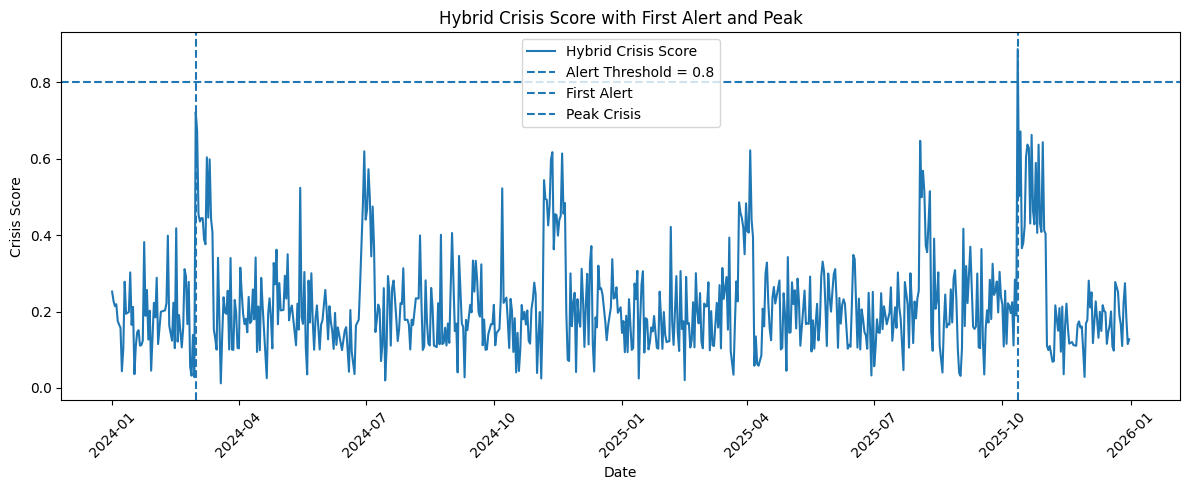

In [ ]:
#60 Plot first alert and peak
plt.figure(figsize=(12, 5))
plt.plot(daily_ts.index, daily_ts["crisis_score"], label="Hybrid Crisis Score")
plt.axhline(y=ALERT_THRESHOLD, linestyle="--", label=f"Alert Threshold = {ALERT_THRESHOLD}")

if first_alert_time is not None:
    plt.axvline(x=first_alert_time, linestyle="--", label="First Alert")

plt.axvline(x=peak_time, linestyle="--", label="Peak Crisis")

plt.title("Hybrid Crisis Score with First Alert and Peak")
plt.xlabel("Date")
plt.ylabel("Crisis Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#61)Top crisis days
top_crisis_days = daily_ts.sort_values("crisis_score", ascending=False).head(10)

print("Top crisis days:")
print(top_crisis_days[[
    "negative_percent",
    "post_volume",
    "anomaly_score",
    "volume_ratio",
    "crisis_score",
    "alert_level"
]])

Top crisis days:
            negative_percent  post_volume  anomaly_score  volume_ratio  \
timestamp                                                                
2025-10-12         82.758621           29            1.0      2.206522   
2024-03-01         76.470588           51            0.4      3.245455   
2024-03-02         76.000000           50            0.4      2.317881   
2025-10-14         82.758621           29            0.4      1.492647   
2025-10-22         85.714286           35            0.4      0.960784   
2025-08-03         55.952381           84            0.4      4.140845   
2025-10-30         82.758621           29            0.4      0.926941   
2025-10-19         80.555556           36            0.4      1.058824   
2025-10-27         79.487179           39            0.4      1.181818   
2025-10-20         79.411765           34            0.4      1.021459   

            crisis_score alert_level  
timestamp                             
2025-10-12      

In [ ]:
#62)Crisis summary table
summary_step10 = pd.DataFrame({
    "Metric": [
        "Peak crisis time",
        "Peak crisis score",
        "Closest alert before peak",
        "Lead-time (days)",
        "Number of alert days"
    ],
    "Value": [
        str(peak_time),
        round(float(peak_score), 4),
        str(closest_alert_time) if closest_alert_time is not None else "None",
        lead_time.days if lead_time is not None else "N/A",
        int(daily_ts["alert_flag"].sum())
    ]
})

print("Crisis Summary:")
print(summary_step10)

Crisis Summary:
                      Metric                Value
0           Peak crisis time  2025-10-12 00:00:00
1          Peak crisis score               0.8866
2  Closest alert before peak  2025-08-05 00:00:00
3           Lead-time (days)                   68
4       Number of alert days                   21


In [ ]:
daily_ts.to_csv("daily_sentiment_with_crisis_score.csv")
summary_step10.to_csv("step10_summary.csv", index=False)
print("Saved crisis score results and summary.")

Saved crisis score results and summary.


In [ ]:
peak_time = daily_ts["crisis_score"].idxmax()

for days in [14, 30, 90]:
    alerts_before_peak = daily_ts[
        (daily_ts.index < peak_time) &
        (daily_ts.index >= peak_time - pd.Timedelta(days=days)) &
        (daily_ts["alert_flag"] == 1)
    ].copy()

    print(f"\nWindow: {days} days")
    print("Alert days:", len(alerts_before_peak))

    if len(alerts_before_peak) > 0:
        first_alert_time = alerts_before_peak.index[0]
        closest_alert_time = alerts_before_peak.index[-1]

        print("First alert in window:", first_alert_time)
        print("Closest alert before peak:", closest_alert_time)
        print("Lead-time from first alert:", (peak_time - first_alert_time).days, "days")
        print("Lead-time from closest alert:", (peak_time - closest_alert_time).days, "days")
    else:
        print("No alert in this pre-crisis window.")


Window: 14 days
Alert days: 0
No alert in this pre-crisis window.

Window: 30 days
Alert days: 0
No alert in this pre-crisis window.

Window: 90 days
Alert days: 2
First alert in window: 2025-08-03 00:00:00
Closest alert before peak: 2025-08-05 00:00:00
Lead-time from first alert: 70 days
Lead-time from closest alert: 68 days


In [ ]:
# 64) Final quick diagnostic checks
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train length:", len(y_train))
print("y_test length:", len(y_test))

print("\nSample X_test:")
print(X_test.head())

print("\nSample y_test:")
print(y_test.head())

X_train shape: (172,)
X_test shape: (44,)
y_train length: 172
y_test length: 44

Sample X_test:
5      h and m uses more synthetic fossil fuel based ...
77     shopping at h and m doesnt feel like a comprom...
347    h and m spring collection is giving high fashi...
254    h and m sustainability targets keep getting pu...
40     hm quality varies significantly between produc...
Name: text_clean, dtype: object

Sample y_test:
5      negative
77     positive
347    positive
254    negative
40      neutral
Name: sentiment, dtype: object


In [ ]:
print(daily_ts["crisis_score"].describe())
print(daily_ts["alert_level"].value_counts())
print(daily_ts[["crisis_score", "alert_level"]].sort_values("crisis_score", ascending=False).head(20))

count    673.000000
mean       0.221183
std        0.129344
min        0.012101
25%        0.126677
50%        0.196680
75%        0.274061
max        0.886552
Name: crisis_score, dtype: float64
alert_level
NORMAL    600
LOW        52
MEDIUM     20
HIGH        1
Name: count, dtype: int64
            crisis_score alert_level
timestamp                           
2025-10-12      0.886552        HIGH
2024-03-01      0.721545      MEDIUM
2024-03-02      0.672665      MEDIUM
2025-10-14      0.671046      MEDIUM
2025-10-22      0.661835      MEDIUM
2025-08-03      0.646389      MEDIUM
2025-10-30      0.642910      MEDIUM
2025-10-19      0.636618      MEDIUM
2025-10-27      0.636503      MEDIUM
2025-10-20      0.628088      MEDIUM
2025-04-03      0.621579      MEDIUM
2024-06-30      0.619059      MEDIUM
2024-11-12      0.616800      MEDIUM
2024-11-19      0.613495      MEDIUM
2025-10-18      0.605704      MEDIUM
2024-03-09      0.603287      MEDIUM
2024-03-11      0.598216      MEDIUM
2024-11-